# 11 — Comparación de Modelos

## Introducción

**Objetivo.** Comparar todos los modelos del marco *screening* con métricas clínicas.

**Fundamento teórico.** La comparación multi-métrica (no solo accuracy) evita conclusiones engañosas en datos desbalanceados.

**Ventajas.** Permite elegir según el objetivo clínico (p. ej. priorizar sensibilidad).

**Limitaciones.** Las métricas dependen del umbral 0.5; conviene analizar curvas y calibración.

**Casos de uso.** Decisión de qué modelo llevar a selección final.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.simplefilter('ignore')
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from predia_ml import config, data, evaluate, plots
pd.set_option('display.max_columns', 60)


In [2]:
comp = pd.read_json(config.METRICS_DIR/'comparison_screening.json').sort_values('roc_auc', ascending=False)
comp[['model','accuracy','roc_auc','recall_sensitivity','specificity','f1','mcc','cv_roc_auc','fit_time_sec']].reset_index(drop=True)

,model,accuracy,roc_auc,recall_sensitivity,specificity,f1,mcc,cv_roc_auc,fit_time_sec
0,logistic_regression,0.6044,0.6591,0.5675,0.6597,0.6325,0.2229,0.6610,8.29
1,hist_gradient_boosting,0.6310,0.6579,0.8391,0.3189,0.7318,0.1856,0.6591,37.77
2,xgboost,0.6289,0.6573,0.8317,0.3246,0.7289,0.1817,0.6587,40.00
3,lightgbm,0.6280,0.6558,0.8387,0.3119,0.7301,0.1776,0.6574,46.67
4,random_forest,0.6244,0.6549,0.8848,0.2340,0.7387,0.1576,0.6573,267.38
5,extra_trees,0.6194,0.6538,0.9220,0.1656,0.7441,0.1356,0.6551,328.92
6,mlp,0.6244,0.6530,0.7937,0.3704,0.7172,0.1807,0.6555,77.21
7,svm,0.6123,0.6328,0.9600,0.0907,0.7482,0.1044,0.6360,244.11
8,knn,0.6003,0.5845,0.8251,0.2631,0.7124,0.1061,0.5872,6.31


### ROC comparativa y barras de AUC / sensibilidad

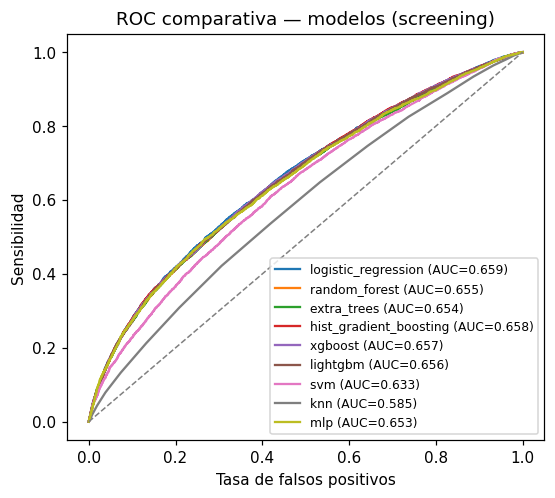

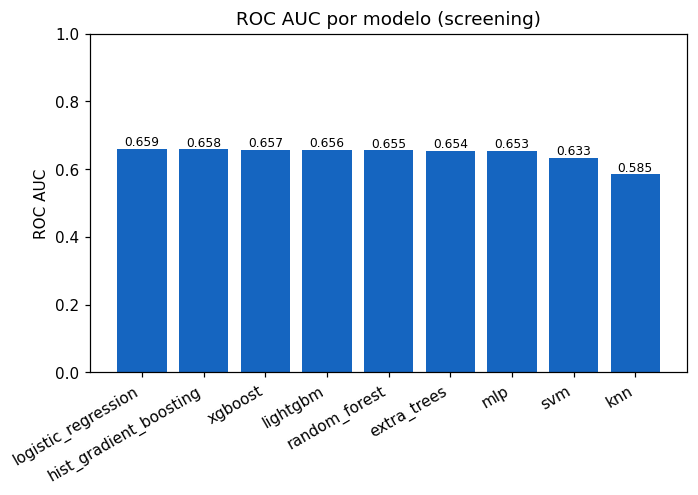

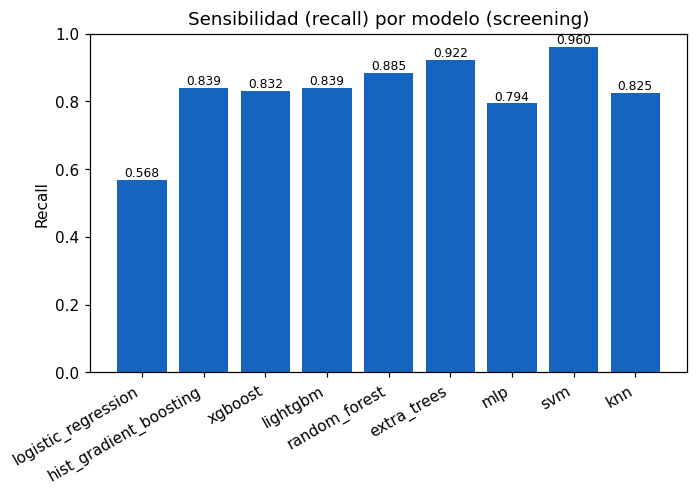

In [3]:
for f in ['comparison_roc.png','comparison_auc.png','comparison_recall.png']:
    display(Image(filename=str(config.FIGURES_DIR/f)))

### Marco *clinical* (con laboratorios diagnósticos): salto por fuga parcial

In [4]:
pd.read_json(config.METRICS_DIR/'comparison_clinical.json')[['model','accuracy','roc_auc','recall_sensitivity']]

,model,accuracy,roc_auc,recall_sensitivity
0,logistic_regression,0.8878,0.9339,0.8775
1,random_forest,0.9196,0.9417,0.8665
2,xgboost,0.9199,0.9444,0.8665
